# MNIST Dataset

In [12]:
import warnings
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from NeuralNetwork import NeuralNetwork
from Scheduler import *
from functions import *

from plotting import set_plot_params

In [2]:
# Load data from https://www.openml.org/d/554
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

In [4]:
# Pre-process data
np.random.seed(2025)
permutation = np.random.permutation(X.shape[0])
# rearrange X and y
X = X[permutation]
y = y[permutation]

def one_hot_rep(data):
    out = np.zeros((np.shape(data)[0], 10))
    for i, point in enumerate(data):
        out[i, int(point)] = 1
    return out

y_onehot = one_hot_rep(y)
#X = X.reshape((X.shape[0], -1))

train_samples = 5000
X_train, X_test, y_train, y_test = train_test_split(
    X, y_onehot, test_size=0.2
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
def accuracy_classifier(probabilities, target):
    correct = 0
    for i, prob in enumerate(probabilities):
        maxprob = np.where(prob < np.max(prob), 0, 1)
        if np.all(maxprob == target[i]):
            correct += 1
    return correct / len(probabilities)
def accuracy_classifier_onehot(predict, target):
    correct = 0
    for i, pred in enumerate(predict):
        if np.all(pred == target[i]):
            correct += 1
    return correct / len(predict)

In [6]:
def dummy(x):
    return None

scheduler = Adam(0.001, first_moment = 0.9, second_moment = 0.999)
classNN = NeuralNetwork(
   784, 10, [50,50], [ReLU, ReLU, softmax], [ReLU_der, ReLU_der, id_func_der],
    scheduler, dummy, dummy, classifier_mode=True, regularization="None", reg_param = 0, seed = 2025
)



In [7]:
# RELU

accuracy_evolve = []
print("BEFORE TRAIN")
#print(classNN._weights_biases[0][0][0][:3])

train_pred = classNN.predict(X_train)
test_pred = classNN.predict(X_test)
#print(train_pred[:3])

test_accuracy = accuracy_classifier(train_pred, y_train)
accuracy_evolve.append(test_accuracy)
print("acc", accuracy_classifier(train_pred, y_train))
print("acc test ", accuracy_classifier(test_pred, y_test))

for i in range(20):
    classNN.train(X_train, y_train,200,1)
    test_pred = classNN.predict(X_test)
    test_accuracy = accuracy_classifier(test_pred, y_test)
    accuracy_evolve.append(test_accuracy)
    
print("AFTER TRAIN")
#print(classNN._weights_biases[0][0][0][:3])
train_pred = classNN.predict(X_train)
test_pred = classNN.predict(X_test)
#print(train_pred[:3])
print("acc train", accuracy_classifier(train_pred, y_train))
print("acc test ", accuracy_classifier(test_pred, y_test))

print(accuracy_evolve)

BEFORE TRAIN
acc 0.09646428571428571
acc test  0.09692857142857143
AFTER TRAIN
acc train 0.9392142857142857
acc test  0.8852142857142857
[0.09646428571428571, 0.5989285714285715, 0.7407142857142858, 0.7902142857142858, 0.8160714285714286, 0.8298571428571428, 0.8430714285714286, 0.8514285714285714, 0.8582142857142857, 0.8603571428571428, 0.8652857142857143, 0.8713571428571428, 0.8735, 0.8776428571428572, 0.8798571428571429, 0.8805714285714286, 0.883, 0.8831428571428571, 0.8844285714285715, 0.8869285714285714, 0.8852142857142857]


In [29]:
scheduler = Adam(0.001, first_moment = 0.9, second_moment = 0.999)
classNNsig = NeuralNetwork(
   784, 10, [50,50], [sigmoid, sigmoid, softmax], [sigmoid_der, sigmoid_der, id_func_der],
    scheduler, dummy, dummy, classifier_mode=True, regularization="None", reg_param = 0, seed = 2025
)

In [30]:
# SIGMOID
accuracy_evolve_sig = []
print("BEFORE TRAIN")
#print(classNNsig._weights_biases[0][0][0][:3])

train_pred = classNNsig.predict(X_train)
test_pred = classNNsig.predict(X_test)
#print(train_pred[:3])

test_accuracy = accuracy_classifier(train_pred, y_train)
accuracy_evolve_sig.append(test_accuracy)
print("acc", accuracy_classifier(train_pred, y_train))
print("acc test ", accuracy_classifier(test_pred, y_test))

for i in range(20):
    classNNsig.train(X_train, y_train,200,1)
    test_pred = classNNsig.predict(X_test)
    test_accuracy = accuracy_classifier(test_pred, y_test)
    accuracy_evolve_sig.append(test_accuracy)
    
print("AFTER TRAIN")
#print(classNNsig._weights_biases[0][0][0][:3])
train_pred = classNNsig.predict(X_train)
test_pred = classNNsig.predict(X_test)
#print(train_pred[:3])
print("acc train", accuracy_classifier(train_pred, y_train))
print("acc test ", accuracy_classifier(test_pred, y_test))

print(accuracy_evolve_sig)

BEFORE TRAIN
acc 0.10642857142857143
acc test  0.10292857142857142
AFTER TRAIN
acc train 0.9429107142857143
acc test  0.899
[0.10642857142857143, 0.5356428571428572, 0.72, 0.7852857142857143, 0.816, 0.8345, 0.8489285714285715, 0.8565714285714285, 0.8621428571428571, 0.8687857142857143, 0.8743571428571428, 0.879, 0.8795714285714286, 0.8844285714285715, 0.887, 0.8895714285714286, 0.8917142857142857, 0.8937142857142857, 0.8949285714285714, 0.8965, 0.899]


In [10]:
skclassifier = MLPClassifier(
    hidden_layer_sizes=(50,50), activation='relu', solver='adam',
    alpha=0, batch_size=200, learning_rate='constant',
    learning_rate_init=0.001, power_t=0.5, max_iter=1,
    shuffle=True, random_state=2025, tol=0, verbose=False,
    warm_start=True, momentum=0, nesterovs_momentum=False,
    early_stopping=False, validation_fraction=0, beta_1=0.9,
    beta_2=0.999, epsilon=1e-08, n_iter_no_change=10, max_fun=15000
)

In [13]:
sk_accuracy_evolve = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for i in range(20):
        skclassifier.fit(X_train,y_train)
        test_skpred = skclassifier.predict(X_test)
        accuracy_sktest = accuracy_classifier_onehot(test_skpred, y_test)
        sk_accuracy_evolve.append(accuracy_sktest)


print("AFTER TRAIN")
train_skpred = skclassifier.predict(X_train)
test_skpred = skclassifier.predict(X_test)
print(train_skpred[0])
print("acc train", accuracy_classifier_onehot(train_skpred, y_train))
print("acc test ", accuracy_classifier_onehot(test_skpred, y_test))

AFTER TRAIN
[0 0 0 0 0 0 0 0 1 0]
acc train 0.9871428571428571
acc test  0.9425


In [24]:
sk_sigclassifier = MLPClassifier(
    hidden_layer_sizes=(50,50), activation='logistic', solver='adam',
    alpha=0, batch_size=200, learning_rate='constant',
    learning_rate_init=0.001, power_t=0.5, max_iter=1,
    shuffle=True, random_state=2025, tol=0, verbose=False,
    warm_start=True, momentum=0, nesterovs_momentum=False,
    early_stopping=False, validation_fraction=0, beta_1=0.9,
    beta_2=0.999, epsilon=1e-08, n_iter_no_change=10, max_fun=15000
)

In [25]:
sk_sig_accuracy_evolve = []
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    for i in range(20):
        sk_sigclassifier.fit(X_train,y_train)
        test_skpred = sk_sigclassifier.predict(X_test)
        accuracy_sktest = accuracy_classifier_onehot(test_skpred, y_test)
        sk_sig_accuracy_evolve.append(accuracy_sktest)


print("AFTER TRAIN")
train_skpred = sk_sigclassifier.predict(X_train)
test_skpred = sk_sigclassifier.predict(X_test)
print(train_skpred[0])
print("acc train", accuracy_classifier_onehot(train_skpred, y_train))
print("acc test ", accuracy_classifier_onehot(test_skpred, y_test))

AFTER TRAIN
[0 0 0 0 0 0 0 0 1 0]
acc train 0.9745892857142857
acc test  0.9355714285714286


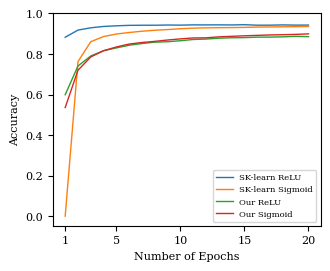

In [37]:
set_plot_params()

runs = range(1,20+1)
plt.plot(runs, sk_accuracy_evolve, label = "SK-learn ReLU")
plt.plot(runs, sk_sig_accuracy_evolve, label = "SK-learn Sigmoid")
plt.plot(runs, accuracy_evolve[1:], label = "Our ReLU")
plt.plot(runs, accuracy_evolve_sig[1:], label = "Our Sigmoid")

plt.yticks([0,0.2,0.4,0.6,0.8,1])
plt.xticks([1,5,10,15,20])
plt.xlabel("Number of Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("../fig/classifier_comparison_sklearn.pdf")